## Model Training

In [33]:
# Suppress Possible Warnings : In some installations a warning due to pyg_lib path can arise: not relevant to our setting
import warnings
warnings.filterwarnings(
    "ignore",
    message=".*An issue occurred while importing 'pyg-lib'.*",
    category=UserWarning,
    module="torch_geometric.typing"
)
warnings.filterwarnings(
    "ignore",
    message=".*An issue occurred while importing 'torch-sparse'.*",
    category=UserWarning,
    module="torch_geometric.typing"
)

In [34]:
import torch
import logging
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from torchinfo import summary
import torch_geometric.utils as pyg_utils
from torch_geometric import seed_everything

from src.config import set_run_dir
from src.config import set_out_dir
from src.config import load_cfg
from src.logger import setup_printing
from src.utils.device import auto_select_device
from src.model.factory import create_model
from src.train.optim import create_optimizer, create_scheduler
from src.dataset.loader import load_data_and_create_dataloader
from src.train.create_trainer import create_trainer
from src.train.optim import create_criterion
from src.train.task import create_task




%load_ext tensorboard
%load_ext autoreload
%autoreload 2


The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load configuration

In [35]:
cfg_file = 'run/configs/swat/gdn.yaml'
cfg = load_cfg(cfg_file)
set_out_dir(cfg.out_dir, cfg_file)
set_run_dir(cfg.out_dir, cfg.seed)

setup_printing(logging.INFO)
seed_everything(cfg.seed)
auto_select_device()

print("=========== Model config summary ===========")
logging.info(cfg.model.gdn)
print("=========== Task summary ===========")
logging.info(cfg.task)

INFO     Mon Sep  1 07:47:25 2025
INFO     Using CPU for training
=========== Model config summary ===========
INFO     embed_dim: 64
out_inter_dim: 64
out_layer_num: 1
outer_dropout: 0.2
topk: 15
=========== Task summary ===========
INFO     anomaly_score_func: node_scaled_topk
anomaly_score_metric: mae
anomaly_score_pak: 50
anomaly_score_sw: 1
anomaly_score_thresh: 1.0
anomaly_score_thresh_mode: val
anomaly_score_topk: 1
combine_type: mapping
detection_delay_ts: 10
gamma: 1.0
level: graph
metric: all
track_graph: True
train_type: forecast
type: anomaly


## Load Dataset

In [36]:
loaders, scaler = load_data_and_create_dataloader()

INFO     
Loaded data from run/datasets/swat
------------ Basic -----------
# Samples: 92496
# Node: 45
# Edges: 1980
# Sequence Length: 5
------------ Fault ratio -----------
# Ratio of fault samples train: 0.000
# Ratio of fault samples test: 0.122
------------ Scaling -----------
[6.68e-01 5.38e-01 8.57e-01 7.42e-01 0.00e+00 6.91e-01 2.45e-01 1.76e-01
 7.31e-01 8.70e-01 0.00e+00 7.40e-01 0.00e+00 6.66e-01 0.00e+00 7.85e-01
 7.76e-01 8.79e-01 5.03e-01 8.99e-01 5.10e-01 5.12e-01 2.63e-05 8.23e-01
 8.41e-01 2.36e-01 9.77e-01 8.72e-01 1.00e+00 0.00e+00 1.00e+00 9.20e-01
 2.47e-01 4.70e-01 1.38e-02 9.77e-01 9.34e-01 9.69e-01 9.74e-01 1.00e+00
 9.56e-01 3.25e-01 9.58e-01 8.07e-03 7.77e-03]
------------ Split -----------
   Train: 38011/92496
Validate: 9499/92496
    Test: 44986/92496



In [37]:
train_loader, eval_laoder, test_loader = loaders

test_batch = next(iter(test_loader))
test_batch

DataBatch(x=[5760, 5], edge_index=[2, 253440], y=[5760, 1], label=[128], batch=[5760], ptr=[129])

### Ex 1: inspect the data

#### visualize the test data (pay attention to the batched data)

In [38]:
x = test_batch.x
print("test_batch.x.shape: ", x.shape)
n_nodes = cfg.dataset.n_nodes
print("number of features n_nodes: ", n_nodes)
ws =  x.shape[1]
print("window size ws: ", ws)

# get the first graph
g0 = test_batch[0]
print("g0 edge_index: ", g0.edge_index.shape)

test_batch.x.shape:  torch.Size([5760, 5])
number of features n_nodes:  45
window size ws:  5
g0 edge_index:  torch.Size([2, 1980])


x.shape:  torch.Size([128, 45, 5])


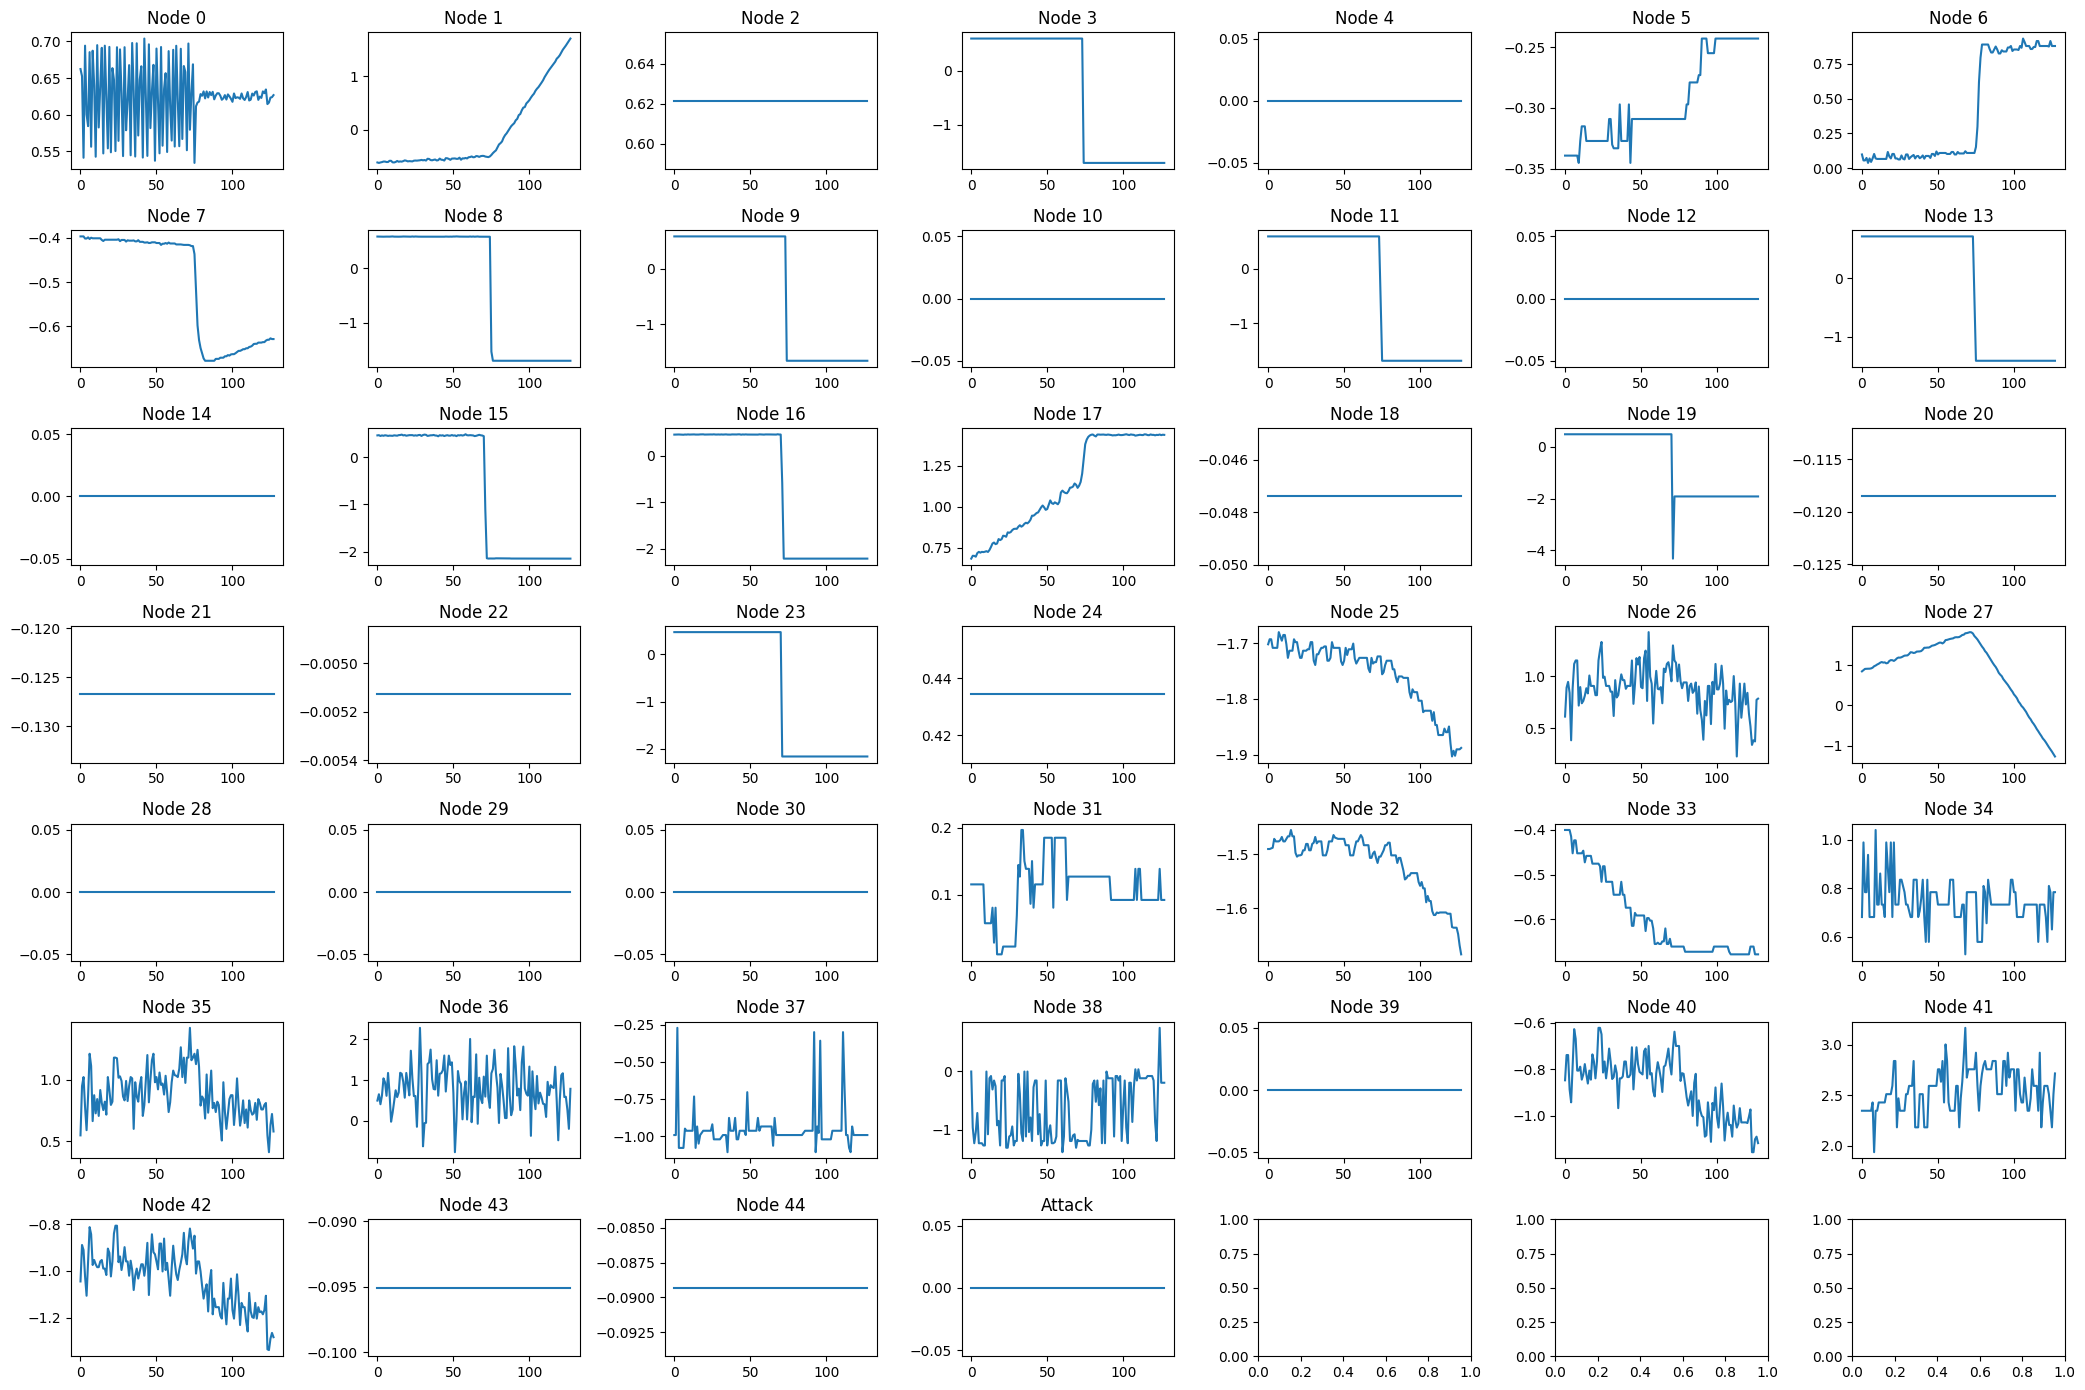

In [39]:
n_cols = int(np.ceil(np.sqrt(n_nodes)))
n_rows = int(np.ceil(n_nodes / n_cols))
f, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2*n_rows))
x = x.view(-1, n_nodes, ws)
print("x.shape: ", x.shape)
for idx in range(n_nodes):
    axes[idx//n_cols, idx%n_cols].plot(x[:, idx, 0])
    axes[idx//n_cols, idx%n_cols].set_title(f"Node {idx}")

axes[n_nodes//n_cols, n_nodes%n_cols].plot(test_batch.label)
axes[n_nodes//n_cols, n_nodes%n_cols].set_title(f"Attack")

plt.tight_layout()
plt.show()

#### Feel free to explore the data

Text(0.5, 1.0, 'Correlation Matrix')

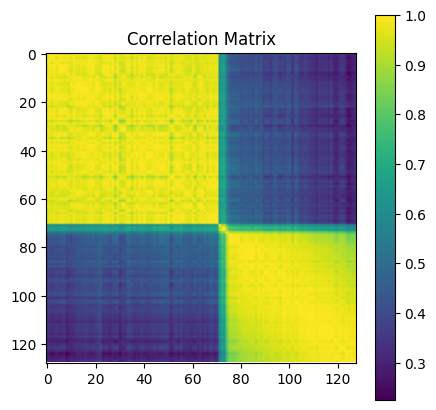

In [40]:
# show correlation matrix
corr = np.corrcoef(x[:, :, 0])
plt.figure(figsize=(5, 5))
plt.imshow(corr, cmap='viridis')
plt.colorbar()
plt.title("Correlation Matrix")

#### visualize the graph of g.edge_index (we start with a fully connected graph)

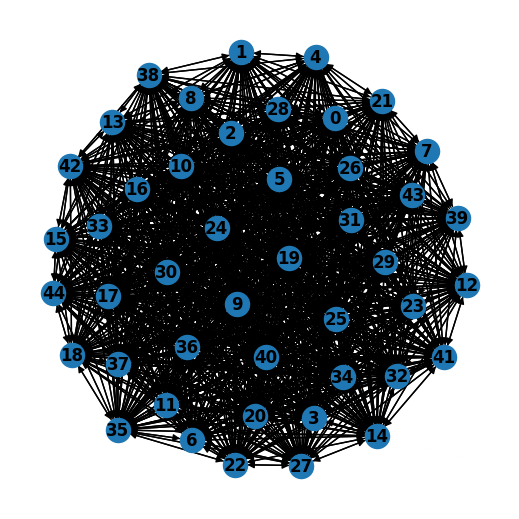

In [41]:
g = pyg_utils.to_networkx(g0)

# draw the graph
plt.figure(figsize=(5, 5))
nx.draw(g, with_labels=True, font_weight='bold')
plt.show()


## Model

In [42]:
model = create_model(cfg.model.type)
summary(model)

INFO     Model GDN parameters: 3841, deployed to cpu
INFO     GDN(
  (embedding): Embedding(45, 64)
  (bn_outlayer_in): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act): ReLU()
  (gnn_layers): ModuleList(
    (0): GNNLayer(
      (gnn): GraphLayer(5, 64, heads=1)
      (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): ReLU()
    )
  )
  (out_layer): OutLayer(
    (mlp): ModuleList(
      (0): Linear(in_features=64, out_features=1, bias=True)
    )
  )
  (dp): Dropout(p=0.2, inplace=False)
)


Layer (type:depth-idx)                   Param #
GDN                                      --
├─Embedding: 1-1                         2,880
├─BatchNorm1d: 1-2                       128
├─ReLU: 1-3                              --
├─ModuleList: 1-4                        --
│    └─GNNLayer: 2-1                     --
│    │    └─GraphLayer: 3-1              640
│    │    └─BatchNorm1d: 3-2             128
│    │    └─ReLU: 3-3                    --
├─OutLayer: 1-5                          --
│    └─ModuleList: 2-2                   --
│    │    └─Linear: 3-4                  65
├─Dropout: 1-6                           --
Total params: 3,841
Trainable params: 3,841
Non-trainable params: 0

## Setup training pipeline

In [43]:
optimizer = create_optimizer(model.parameters())
scheduler = create_scheduler(optimizer)

crit_type = cfg.optim.criterion
criterion = create_criterion(crit_type, mask_loss=False)

task = create_task(
    cfg.task.type, 
    task_train_type=cfg.task.train_type, 
    track_graph=False,
)

trainer = create_trainer(
    model, 
    optimizer=optimizer, 
    neptune_writer=None,
    scheduler=scheduler, 
    criterion=criterion, 
    scaler=scaler,
    task=task,
)

INFO     Create AnomalyDetectionTask.
INFO     Create ForecastingTrainer.


### Training

In [ ]:
trainer.fit(loaders)

### Using tensorboard

In [ ]:
from torch.utils.tensorboard import SummaryWriter

In [ ]:

#%tensorboard --logdir run/results/anomaly/swat --port 6006
